# Business Case: Walmart - Confidence Interval and CLT


## 1.Introduction
###About Walmart ?
Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.
###Objective:
The objective of this project is to conduct a comprehensive analysis of customer purchase behavior, with a specific focus on purchase amounts, in relation to customer gender
during the Black Friday sales event at Walmart Inc. This study aims to provide valuable insights that can assist the management team at Walmart Inc. in making data-driven
decisions.

##2.Exploratory Data Analysis

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t
import warnings
warnings.filterwarnings('ignore')
import copy

In [ ]:
df=pd.read_csv("walmart_data.txt")

In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
df.shape

(550068, 10)

In [ ]:
df.isnull().sum() #No missing values in dataset

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

In [ ]:
df.nunique()

User_ID                        5891
Product_ID                     3631
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category                 20
Purchase                      18105
dtype: int64

**`Insights`**
- There are total **`550068`** datapoints out of which only **`5891`** User_ID found means same users bought multiple product or do multiple transactions.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


No. of categorical feature - 5

No. of continuous (numerical) feature - 5

In [ ]:
cat_cols = ["User_ID", "Product_ID", "Gender", "Age", "City_Category", "Marital_Status"]

for i in cat_cols:
    df[i] = df[i].astype("category")

df.dtypes

User_ID                       category
Product_ID                    category
Gender                        category
Age                           category
Occupation                       int64
City_Category                 category
Stay_In_Current_City_Years      object
Marital_Status                category
Product_Category                 int64
Purchase                         int64
dtype: object

In [ ]:
df.describe()

,Occupation,Product_Category,Purchase
count,550068.000000,550068.000000,550068.000000
mean,8.076707,5.404270,9263.968713
std,6.522660,3.936211,5023.065394
min,0.000000,1.000000,12.000000
25%,2.000000,1.000000,5823.000000
50%,7.000000,5.000000,8047.000000
75%,14.000000,8.000000,12054.000000
max,20.000000,20.000000,23961.000000


- As it is quite obvious that there is significant difference in the mean and std for Purchase column which might be containing outliers.


In [ ]:
df.describe(include = ['object','category'])

,User_ID,Product_ID,Gender,Age,City_Category,Stay_In_Current_City_Years,Marital_Status
count,550068,550068,550068,550068,550068,550068,550068
unique,5891,3631,2,7,3,5,2
top,1001680,P00265242,M,26-35,B,1,0
freq,1026,1880,414259,219587,231173,193821,324731


- Customer (1001680) has purchased more than others

- Product (P00265242) is most bought item

- Most of the customers are Male

- Most of customers lies in [26-35] Age bracket

- Majority of the customers are Unmarried

In [ ]:
df.duplicated().sum()

0

# Non-Graphical Analysis

### Value counts and Unique Attributes

In [ ]:
df.groupby(["Gender"])["User_ID"].nunique() / df["User_ID"].nunique() * 100

Gender
F    28.280428
M    71.719572
Name: User_ID, dtype: float64

In [ ]:
df.groupby(["Gender"])["Purchase"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,135809.0,8734.565765,4767.233289,12.0,5433.0,7914.0,11400.0,23959.0
M,414259.0,9437.526040,5092.186210,12.0,5863.0,8098.0,12454.0,23961.0


- **`There are only 28% female customers. While male customers constitute around 72% in our dataset`**

In [ ]:
df.groupby(["Age"])["User_ID"].nunique() / df["User_ID"].nunique() * 100

Age
0-17      3.700560
18-25    18.146325
26-35    34.849771
36-45    19.809879
46-50     9.013750
51-55     8.164997
55+       6.314717
Name: User_ID, dtype: float64

In [ ]:
df.groupby(["Age"])["Purchase"].describe()

,count,mean,std,min,25%,50%,75%,max
Age,,,,,,,,
0-17,15102.0,8933.464640,5111.114046,12.0,5328.0,7986.0,11874.0,23955.0
18-25,99660.0,9169.663606,5034.321997,12.0,5415.0,8027.0,12028.0,23958.0
26-35,219587.0,9252.690633,5010.527303,12.0,5475.0,8030.0,12047.0,23961.0
36-45,110013.0,9331.350695,5022.923879,12.0,5876.0,8061.0,12107.0,23960.0
46-50,45701.0,9208.625697,4967.216367,12.0,5888.0,8036.0,11997.0,23960.0
51-55,38501.0,9534.808031,5087.368080,12.0,6017.0,8130.0,12462.0,23960.0
55+,21504.0,9336.280459,5011.493996,12.0,6018.0,8105.5,11932.0,23960.0


- Around 35% customers are in [26-35] age bracket. On other hand customers in age bracket [0-17], [51-55] & [55+] showing less purchasing behaviour.

In [ ]:
df.groupby(["Stay_In_Current_City_Years"])["User_ID"].nunique()

Stay_In_Current_City_Years
0      772
1     2086
2     1145
3      979
4+     909
Name: User_ID, dtype: int64

- Customers staying for 1-2 years in same city purchased more than others

In [ ]:
df.groupby(["Marital_Status"])["User_ID"].nunique() / df["User_ID"].nunique() * 100

Marital_Status
0    58.003735
1    41.996265
Name: User_ID, dtype: float64

- 58:42 is the ratio between married and unmarried customers

In [ ]:
df.groupby(["City_Category"])["User_ID"].nunique()

City_Category
A    1045
B    1707
C    3139
Name: User_ID, dtype: int64

- Most of customers belogs to C city_category

In [ ]:
df.groupby(['City_Category'])['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
City_Category,,,,,,,,
A,147720.0,8911.939216,4892.115238,12.0,5403.0,7931.0,11786.0,23961.0
B,231173.0,9151.300563,4955.496566,12.0,5460.0,8005.0,11986.0,23960.0
C,171175.0,9719.920993,5189.465121,12.0,6031.5,8585.0,13197.0,23961.0


- Most of the customers belongs to City C But customers from city_category B tend to purchase more suggest the fact they visit store multiple times during that period

In [ ]:
categorical_cols = ['Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category']
df[categorical_cols].melt().groupby(['variable', 'value'])[['value']].count()/len(df)

value
variable                   value          
Age                        0-17   0.027455
                           18-25  0.181178
                           26-35  0.399200
                           36-45  0.199999
                           46-50  0.083082
                           51-55  0.069993
                           55+    0.039093
City_Category              A      0.268549
                           B      0.420263
                           C      0.311189
Gender                     F      0.246895
                           M      0.753105
Marital_Status             0      0.590347
                           1      0.409653
Occupation                 0      0.126599
                           1      0.086218
                           2      0.048336
                           3      0.032087
                           4      0.131453
                           5      0.022137
                           6      0.037005
                           7      0.107501
                           8      0.002811
                           9      0.011437
                           10     0.023506
                           11     0.021063
                           12     0.056682
                           13     0.014049
                           14     0.049647
                           15     0.022115
                           16     0.046123
                           17     0.072796
                           18     0.012039
                           19     0.015382
                           20     0.061014
Product_Category           1      0.255201
                           2      0.043384
                           3      0.036746
                           4      0.021366
                           5      0.274390
                           6      0.037206
                           7      0.006765
                           8      0.207111
                           9      0.000745
                           10     0.009317
                           11     0.044153
                           12     0.007175
                           13     0.010088
                           14     0.002769
                           15     0.011435
                           16     0.017867
                           17     0.001051
                           18     0.005681
                           19     0.002914
                           20     0.004636
Stay_In_Current_City_Years 0      0.135252
                           1      0.352358
                           2      0.185137
                           3      0.173224
                           4+     0.154028

#### Observations
- ~ 80% of the users are between the age 18-50 (40%: 26-35, 18%: 18-25, 20%: 36-45)
- 75% of the users are **`Male`** and 25% are **`Female`**
- 60% Single, 40% Married
- 35% Staying in the city from 1 year, 18% from 2 years, 17% from 3 years
- Total of 20 product categories are there
- There are 20 differnent types of occupations in the city

#3.Graphical Analysis

## Univariate Countinous Variable Analysis

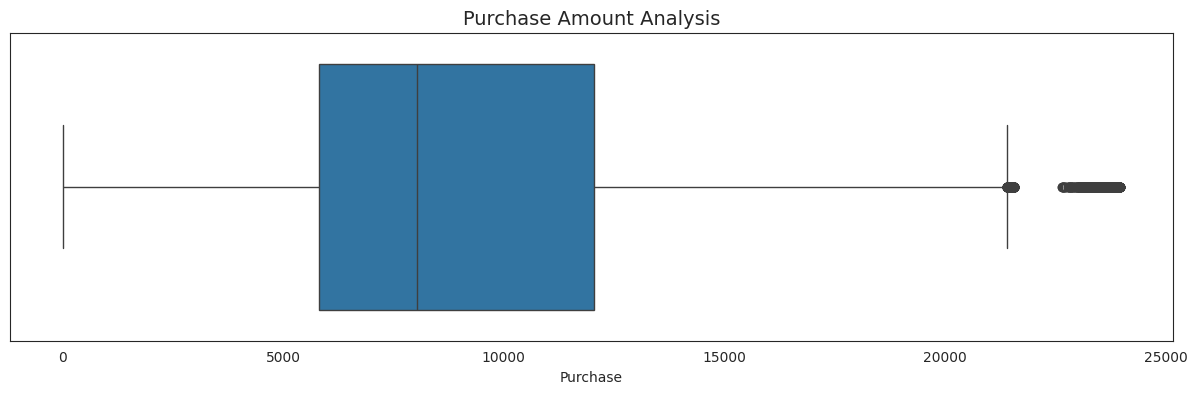

In [ ]:
fig = plt.figure(figsize=(15,4))
sns.set_style("white")
sns.boxplot(data = df, x = "Purchase", orient = "h")
plt.title('Purchase Amount Analysis', fontsize = '14')
plt.show()

**`Insights`**
- There are outliers in purchase amount.
- While observing the distribution of purchase amount from density plot. It is quite obvious that the distribution is right skewed means majority of data concentrated on left side.
- Majority of customer purchase within 5,000 - 20,000 range.

# Detecting Outliers

In [ ]:
print('Mean of Purchase Amount   = ', df["Purchase"].mean())
print('Median of Purchase Amount = ', df["Purchase"].median()) #Lot of Difference in Mean and Median tells there are outliers

Mean of Purchase Amount   =  9263.968712959126
Median of Purchase Amount =  8047.0


# Handling Outliers

In [ ]:
q1 = df["Purchase"].quantile(0.25)
q3 = df["Purchase"].quantile(0.75)

IQR = q3 - q1
print("1. First Quartile (q1) = ", q1)
print("2. Third Quartile (q2) = ", q3)
print("3. IQR                 = ", IQR)

1. First Quartile (q1) =  5823.0
2. Third Quartile (q2) =  12054.0
3. IQR                 =  6231.0


In [ ]:
df_new = df.copy()

df_new["Purchase"] = np.clip(df_new["Purchase"], q1-1.5*IQR, q3 + 1.5*IQR)
df_new.shape

(550068, 10)

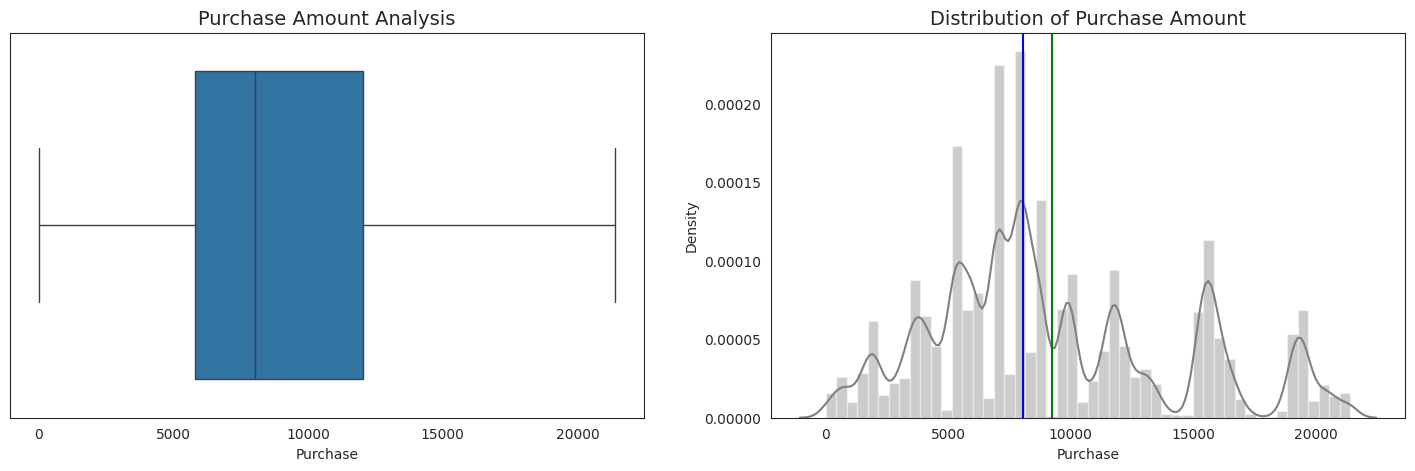

In [ ]:
fig = plt.figure(figsize=(18,5))
sns.set_style("white")

plt.subplot(1, 2, 1)
sns.boxplot(data = df_new, x = "Purchase", orient = "h")

plt.title('Purchase Amount Analysis', fontsize = '14')


plt.subplot(1, 2, 2)
sns.distplot(a = df_new["Purchase"], color = 'grey')
plt.title("Distribution of Purchase Amount", fontsize = '14')
plt.axvline(df_new["Purchase"].mean(),color="g")
plt.axvline(df_new["Purchase"].median(),color="b")

plt.show()

Outliers are Handled using IQR and updatind the dataset values

# Univariate Categorical Variable Analysis

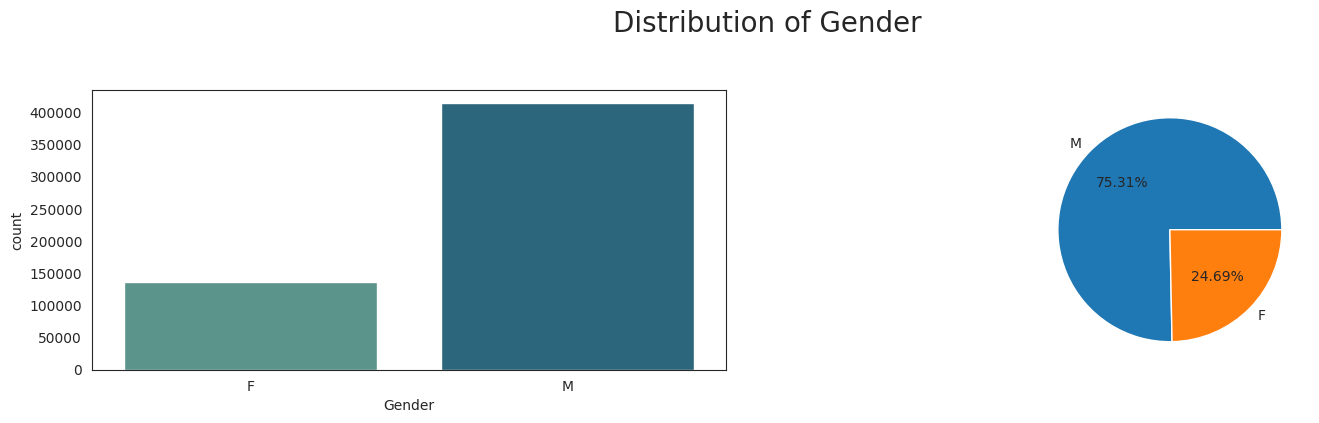

In [ ]:
fig = plt.figure(figsize=(18,8))
sns.set_style(style='white')
ax1 = plt.subplot2grid((2,2),(0,0))
sns.countplot(data=df, x="Gender", palette="crest")

#first row sec column
ax1 = plt.subplot2grid((2,2), (0, 1))
plt.pie(df_new["Gender"].value_counts(),
        labels = df["Gender"].value_counts().index,
        autopct = '%1.2f%%')
plt.suptitle('Distribution of Gender', fontsize = 20)

plt.show()

**`Insights`**

- Males clearly purchase more than females. 75% of men and only 25% of women purchase products.

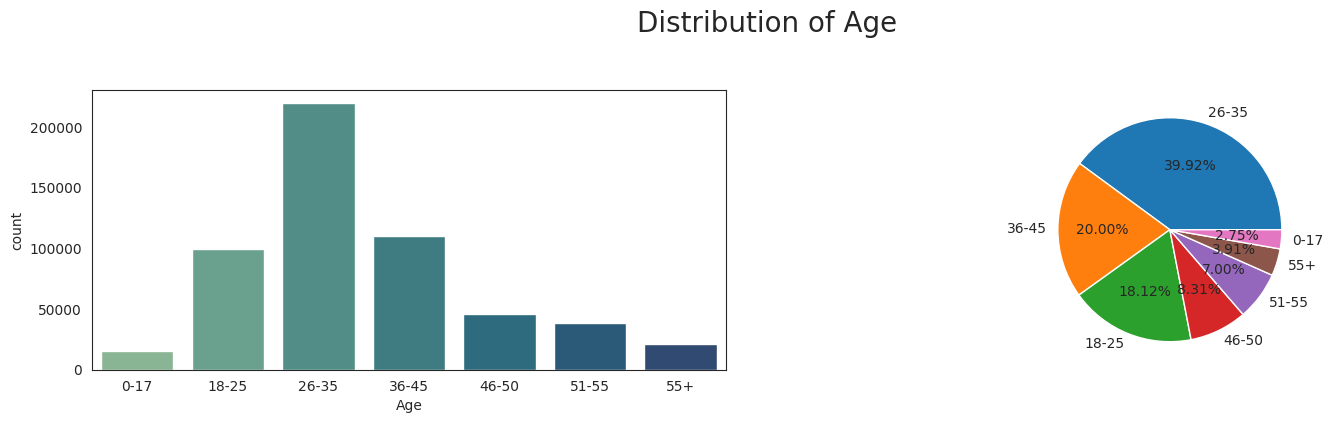

In [ ]:
fig = plt.figure(figsize=(18,8))
sns.set_style(style='white')
ax1 = plt.subplot2grid((2,2),(0,0))
sns.countplot(data=df, x="Age", palette="crest")

#first row sec column
ax1 = plt.subplot2grid((2,2), (0, 1))
plt.pie(df_new["Age"].value_counts(),
        labels = df["Age"].value_counts().index,
        autopct = '%1.2f%%')
plt.suptitle('Distribution of Age', fontsize = 20)

plt.show()

**`Insights`**

- 60% of purchases are made by people between the ages of 26 and 45

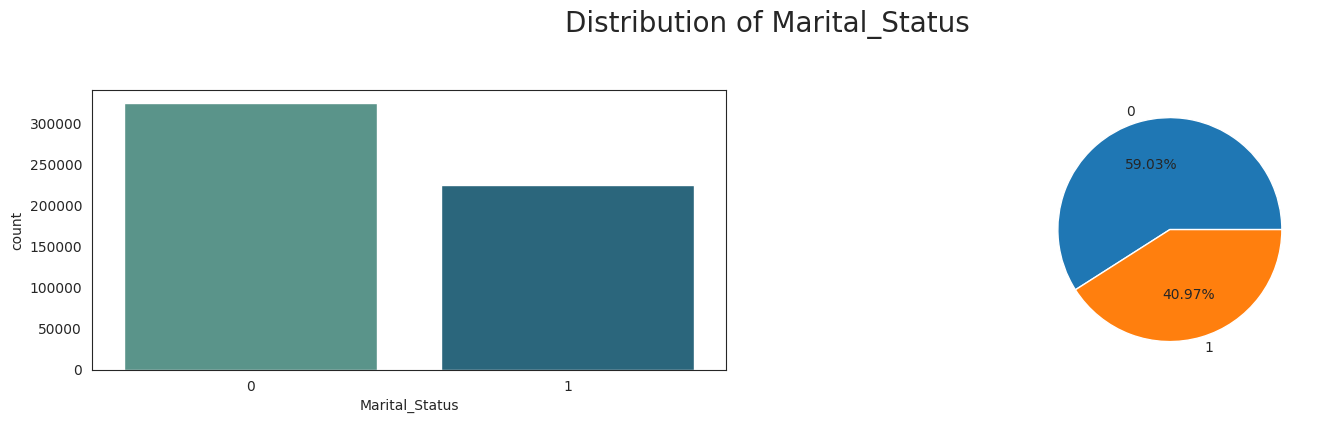

In [ ]:
fig = plt.figure(figsize=(18,8))
sns.set_style(style='white')
ax1 = plt.subplot2grid((2,2),(0,0))
sns.countplot(data=df, x="Marital_Status", palette="crest")

ax1 = plt.subplot2grid((2,2), (0, 1))
plt.pie(df_new["Marital_Status"].value_counts(),
        labels = df["Marital_Status"].value_counts().index,
        autopct = '%1.2f%%')
plt.suptitle('Distribution of Marital_Status', fontsize = 20)

plt.show()

**`Insights`**

- Most of customers are unmarried.

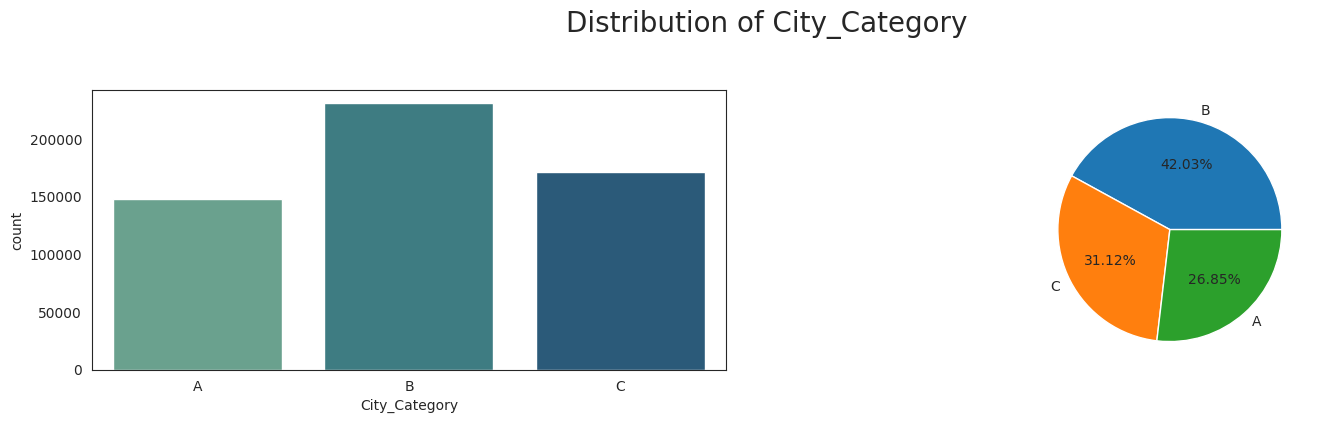

In [ ]:
fig = plt.figure(figsize=(18,8))
sns.set_style(style='white')
ax1 = plt.subplot2grid((2,2),(0,0))
sns.countplot(data=df, x="City_Category", palette="crest")

#first row sec column
ax1 = plt.subplot2grid((2,2), (0, 1))
plt.pie(df_new["City_Category"].value_counts(),
        labels = df["City_Category"].value_counts().index,
        autopct = '%1.2f%%')
plt.suptitle('Distribution of City_Category', fontsize = 20)

plt.show()

**`Insights`**

- `City Category B` accounts for 42%, `City Category C` 31%, and `City Category A` represents 27% of all customer purchases.

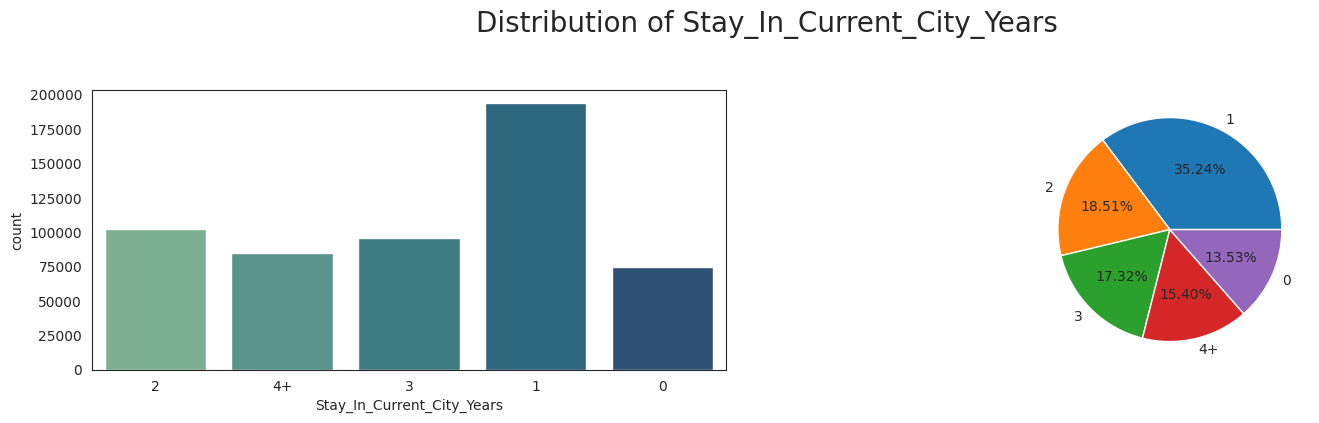

In [ ]:
fig = plt.figure(figsize=(18,8))
sns.set_style(style='white')
ax1 = plt.subplot2grid((2,2),(0,0))
sns.countplot(data=df, x="Stay_In_Current_City_Years", palette="crest")

#first row sec column
ax1 = plt.subplot2grid((2,2), (0, 1))
plt.pie(df_new["Stay_In_Current_City_Years"].value_counts(),
        labels = df["Stay_In_Current_City_Years"].value_counts().index,
        autopct = '%1.2f%%')
plt.suptitle('Distribution of Stay_In_Current_City_Years', fontsize = 20)
plt.show()

**`Insights`**
- Most of customer stayed around 1 years in the current city

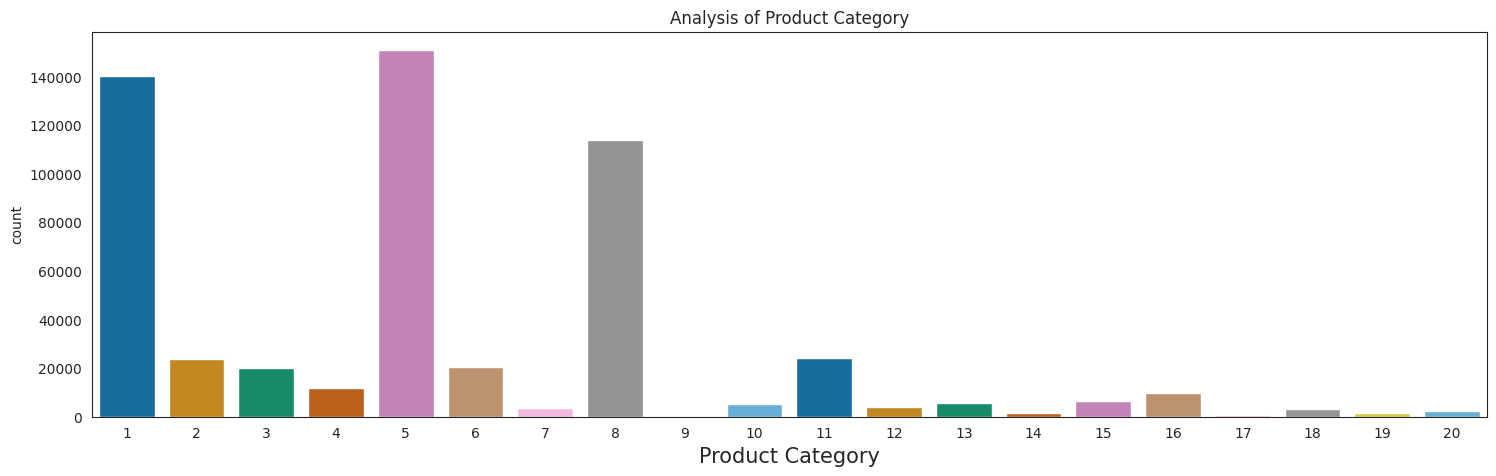

In [ ]:
fig = plt.figure(figsize = (18,5))

sns.countplot(data = df, x = "Product_Category", palette="colorblind")
plt.xlabel("Product Category", fontsize = 15)
plt.title("Analysis of Product Category")
plt.show()

**`Insights`**
- Product categories 1, 5 and 8 most bought products.

# Bivariate Analysis

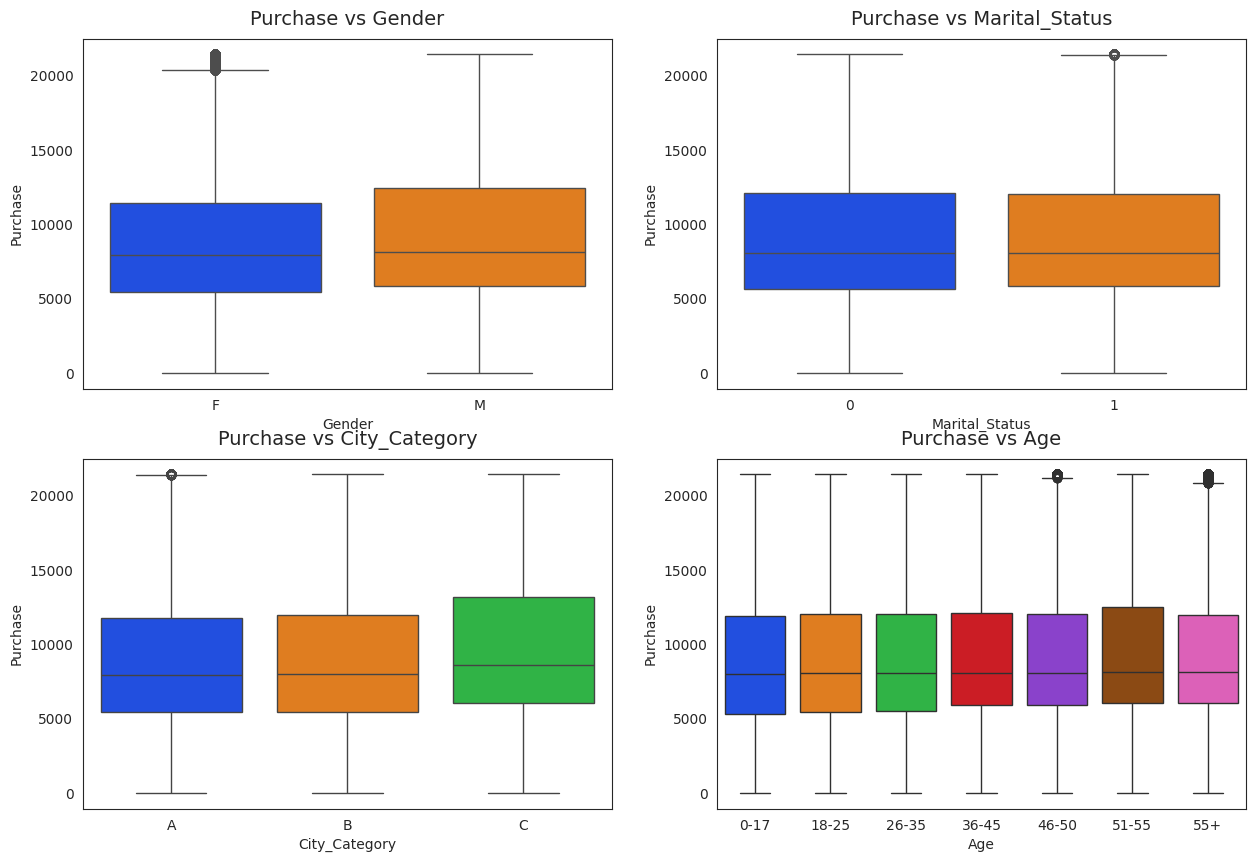

In [ ]:
cat_col = ["Gender", "Marital_Status", "City_Category", "Age"]

fig, axs = plt.subplots(nrows=2, ncols = 2, figsize=(15,10))
k = 0
sns.set_style("dark")
for i in range(2):
    for j in range(2):
        sns.boxplot(data=df_new, x=cat_col[k], y="Purchase", palette='bright', ax=axs[i, j])
        axs[i, j].set_title("Purchase vs " + cat_col[k], pad = 10, fontsize = 14)
        k += 1
plt.show()

**`Insights`**
- Customers puchasing behaviour are almost stable at equilibrium irrespective on `Gender`, `Marital_status`, `City_Category` & `Age`
- Median purchase from each features are almost same

# Lets draw analysis for Gender

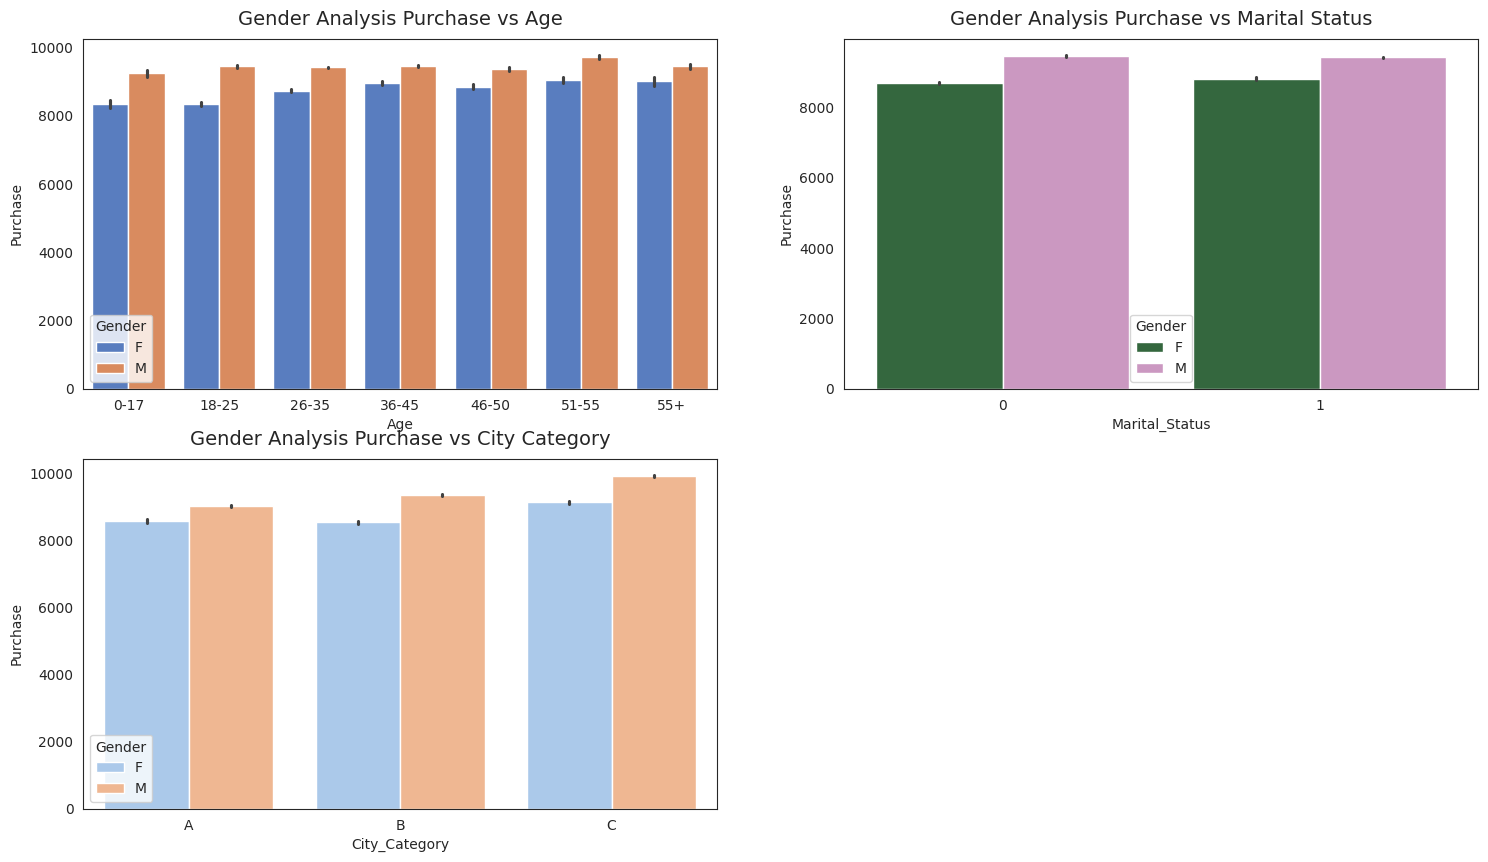

In [ ]:
fig = plt.figure(figsize=(18, 10))

sns.set_style("white")

ax1 = plt.subplot2grid((2, 2), (0, 0))
sns.barplot(data=df, x = "Age", y = "Purchase", ax=ax1, hue = "Gender", palette="muted")
plt.title("Gender Analysis Purchase vs Age", pad = 10, fontsize = 14)

ax1 = plt.subplot2grid((2, 2), (0, 1))
sns.barplot(data=df, x = "Marital_Status", y = "Purchase", ax=ax1, hue = "Gender", palette="cubehelix")
plt.title("Gender Analysis Purchase vs Marital Status", pad = 10, fontsize = 14)

ax1 = plt.subplot2grid((2, 2), (1, 0))
sns.barplot(data=df, x = "City_Category", y = "Purchase", ax=ax1, hue = "Gender", palette="pastel")
plt.title("Gender Analysis Purchase vs City Category", pad = 10, fontsize = 14)

plt.show()

**`Insights`**
- Purchases are high in city category C
- Purchase is the somehow same for all age groups
- Female Customers form City category C is more than other city category
- Purchases are same for all Marital Status

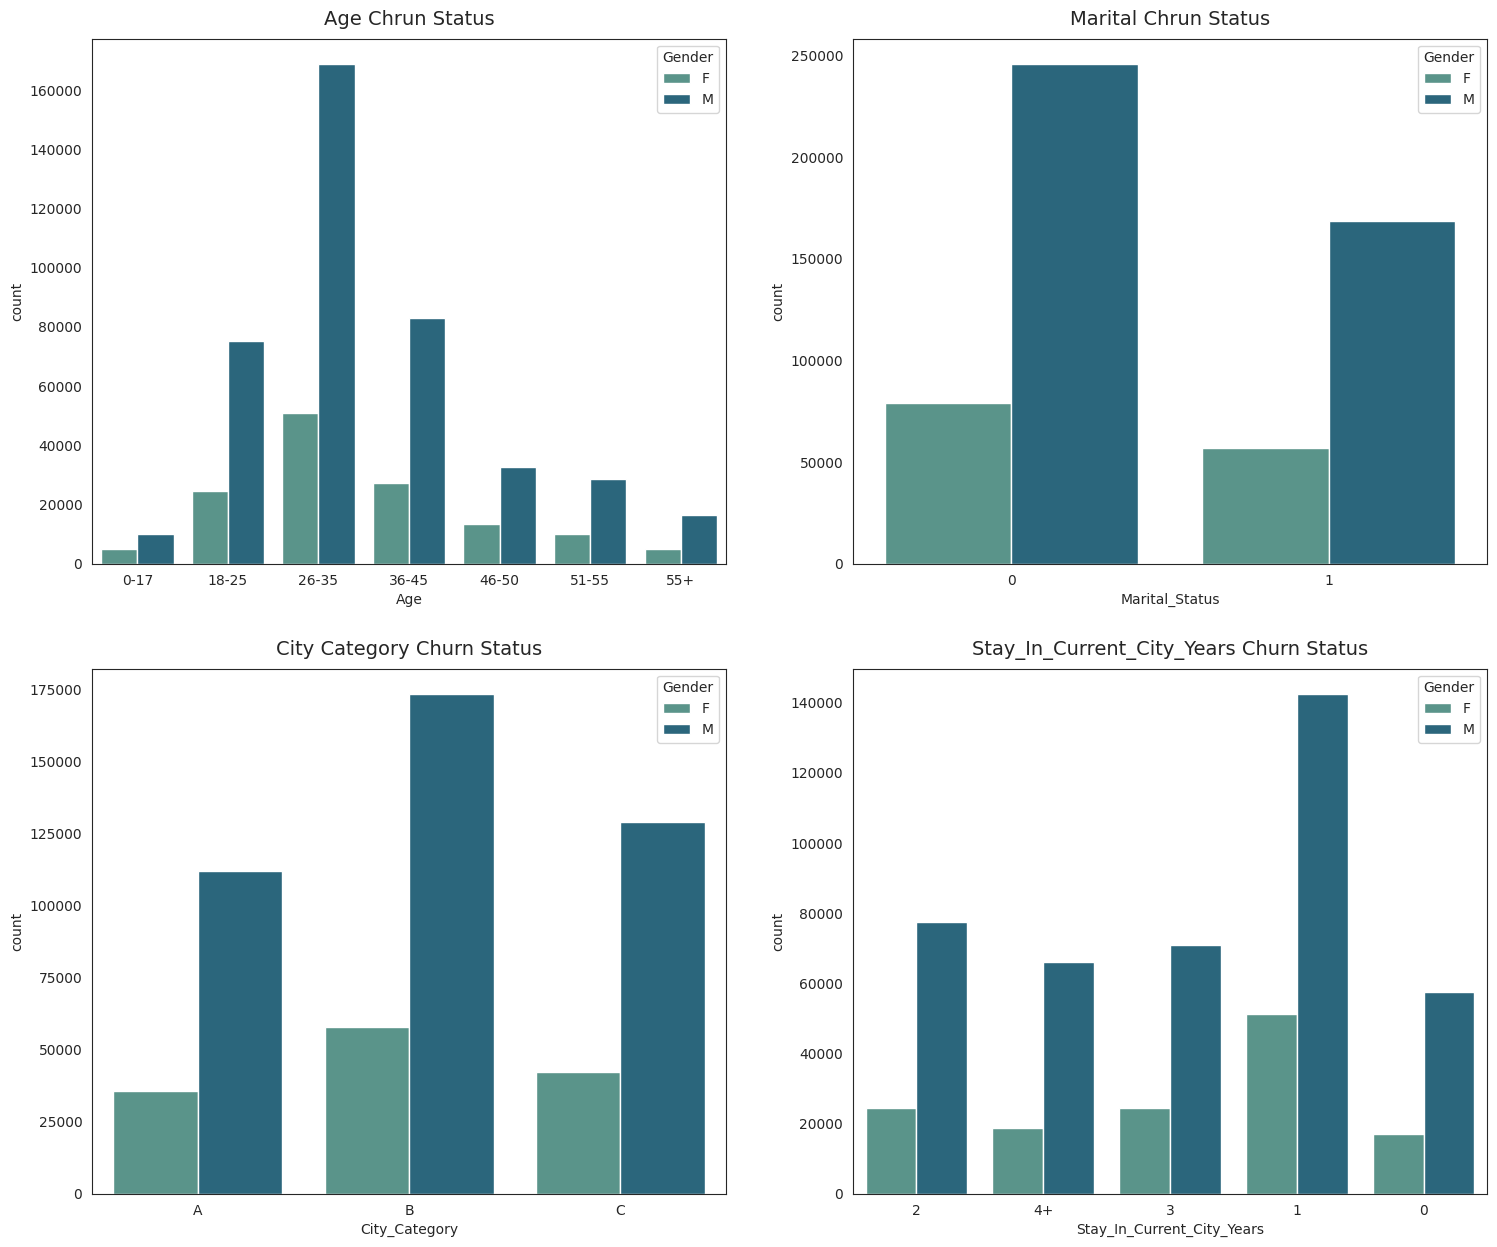

In [ ]:
fig = plt.figure(figsize=(18, 15))

sns.set_style("white")

ax1 = plt.subplot2grid((2, 2), (0, 0))
sns.countplot(data=df, x = "Age", ax=ax1, hue = "Gender", palette="crest")
plt.title("Age Chrun Status", pad = 10, fontsize = 14)

ax1 = plt.subplot2grid((2, 2), (0, 1))
sns.countplot(data=df, x = "Marital_Status", ax=ax1, hue = "Gender", palette="crest")
plt.title("Marital Chrun Status", pad = 10, fontsize = 14)

ax1 = plt.subplot2grid((2, 2), (1, 0))
sns.countplot(data=df, x = "City_Category", ax=ax1, hue = "Gender", palette="crest")
plt.title("City Category Churn Status", pad = 10, fontsize = 14)

ax1 = plt.subplot2grid((2, 2), (1, 1))
sns.countplot(data=df, x = "Stay_In_Current_City_Years", ax=ax1, hue = "Gender", palette="crest")
plt.title("Stay_In_Current_City_Years Churn Status", pad = 10, fontsize = 14)

plt.show()

**`Insights`**
- Most of female customers are from city category C
- Most of female customer stay 1 year in the current city than others
- Most of the customers are in range 18-45 age bracket
- There is huge difference in the male and female customer for age bracket [26-35]
- There is significant difference of male customers. Most of the male customers are single. While female customers marital status not more significant as there is not so much difference.

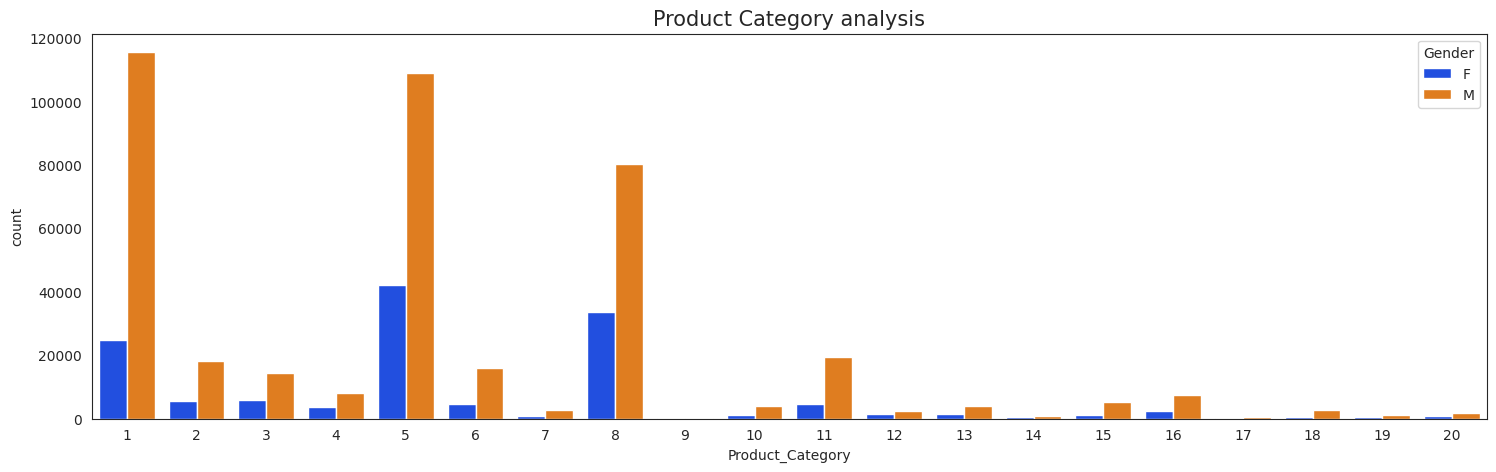

In [ ]:
fig = plt.figure(figsize=(18, 5))

plt.title("Product Category analysis", fontsize = 15)
sns.countplot(data=df, x = "Product_Category", hue = "Gender", palette="bright")

plt.show()

**`Insights`**
- Product Category 5 and 8 are demanding among female customers
- Proudct Category 1 and 5 are most demanding among male customers

# Lets draw analysis for City Category Among Different Age Brackets

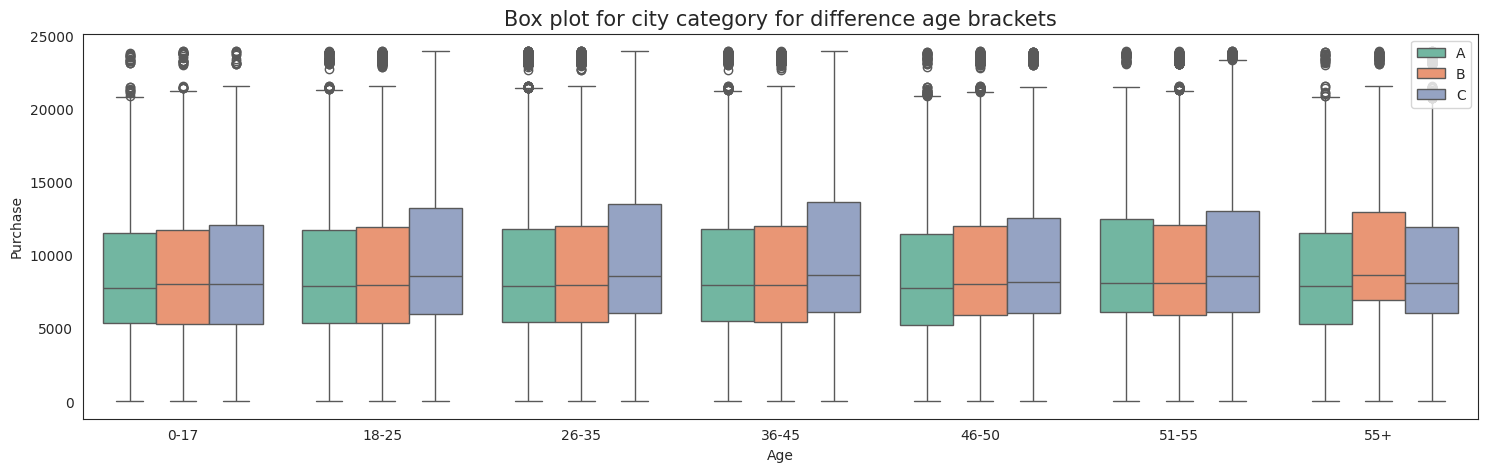

In [ ]:
fig = plt.figure(figsize=(18, 5))

plt.title("Box plot for city category for difference age brackets", fontsize = 15)
sns.boxplot(data=df, x = "Age", y = "Purchase", hue = "City_Category", palette="Set2")

plt.legend(loc = "upper right")
plt.show()

**`Insights`**
- Product Category B is popular among age group 55+
- Product Category A & B are quite same in demand among other age groups except 55+
- While Product Category C is in demand for age group 18-45 and slightly in 51-55 age group

# Correlation Analysis

In [ ]:
df_new.corr()

,Occupation,Product_Category,Purchase
Occupation,1.000000,-0.007618,0.020853
Product_Category,-0.007618,1.000000,-0.347413
Purchase,0.020853,-0.347413,1.000000


Correlation is a statistical measure that describes the strength and direction of a relationship between two variables.

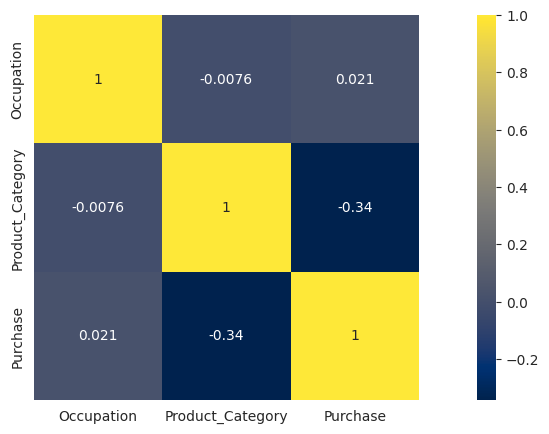

In [ ]:
plt.figure(figsize = (15, 5))
sns.heatmap(data=df.corr(), annot=True, cmap="cividis", square=True)
plt.show()

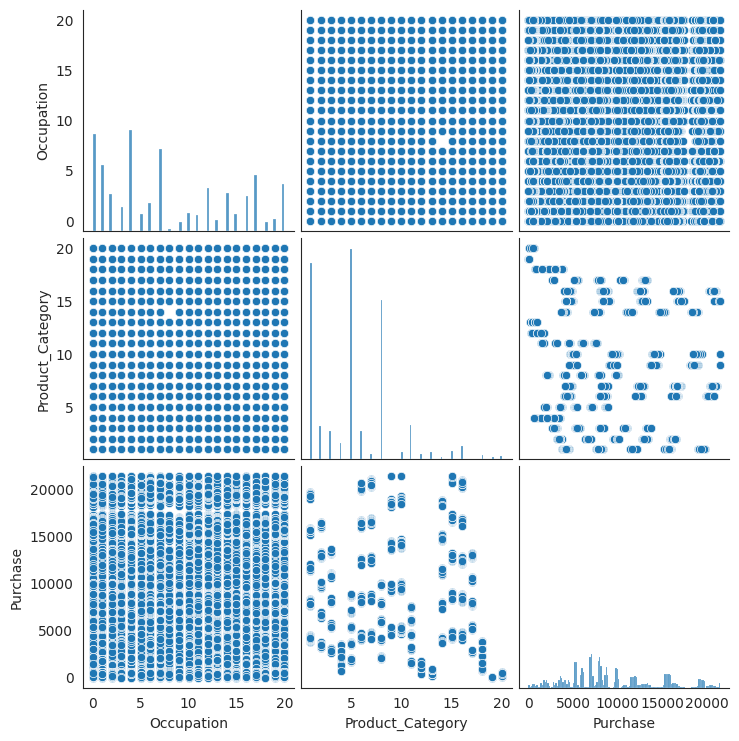

In [ ]:
sns.pairplot(df_new)
plt.show()

**`Insights`**
- Our dataset is hightly categorial variable centric. So we can hardly find correlation in our dataset.

# 4. Answering questions

## 4.1  Are women spending more money per transaction than men? Why or Why not?

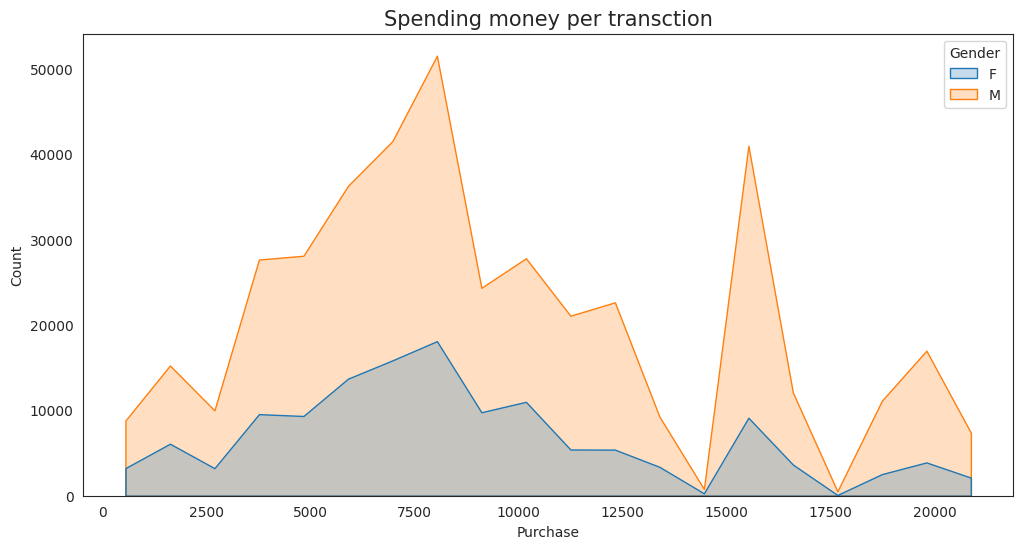

In [ ]:
plt.figure(figsize=(12, 6))

plt.title("Spending money per transction", fontsize = 15)
sns.histplot(data=df_new, x = "Purchase", bins=20, hue = "Gender", element="poly")

plt.show()

**`Insights`**
- The amount of money spent by women customers per transaction is quite less than that of men.

# 4.2 Confidence intervals and distribution of the mean of the expenses by female and male customers

In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
amt_df = df.groupby(['User_ID', 'Gender'])[['Purchase']].sum()
amt_df = amt_df.reset_index()
amt_df

,User_ID,Gender,Purchase
0,1000001,F,334093
1,1000001,M,0
2,1000002,F,0
3,1000002,M,810472
4,1000003,F,0
...,...,...,...
11777,1006038,M,0
11778,1006039,F,590319
11779,1006039,M,0
11780,1006040,F,0


In [ ]:
male_df = amt_df[amt_df['Gender']=='M']
female_df = amt_df[amt_df['Gender']=='F']
amt_df['Gender'].value_counts()

F    5891
M    5891
Name: Gender, dtype: int64

In [ ]:
genders = ["M", "F"]

male_sample_size = 3000
female_sample_size = 1500
num_repitions = 1000
male_means = []
female_means = []

for _ in range(num_repitions):
    male_mean = male_df.sample(male_sample_size, replace=True)['Purchase'].mean()
    female_mean = female_df.sample(female_sample_size, replace=True)['Purchase'].mean()

    male_means.append(male_mean)
    female_means.append(female_mean)

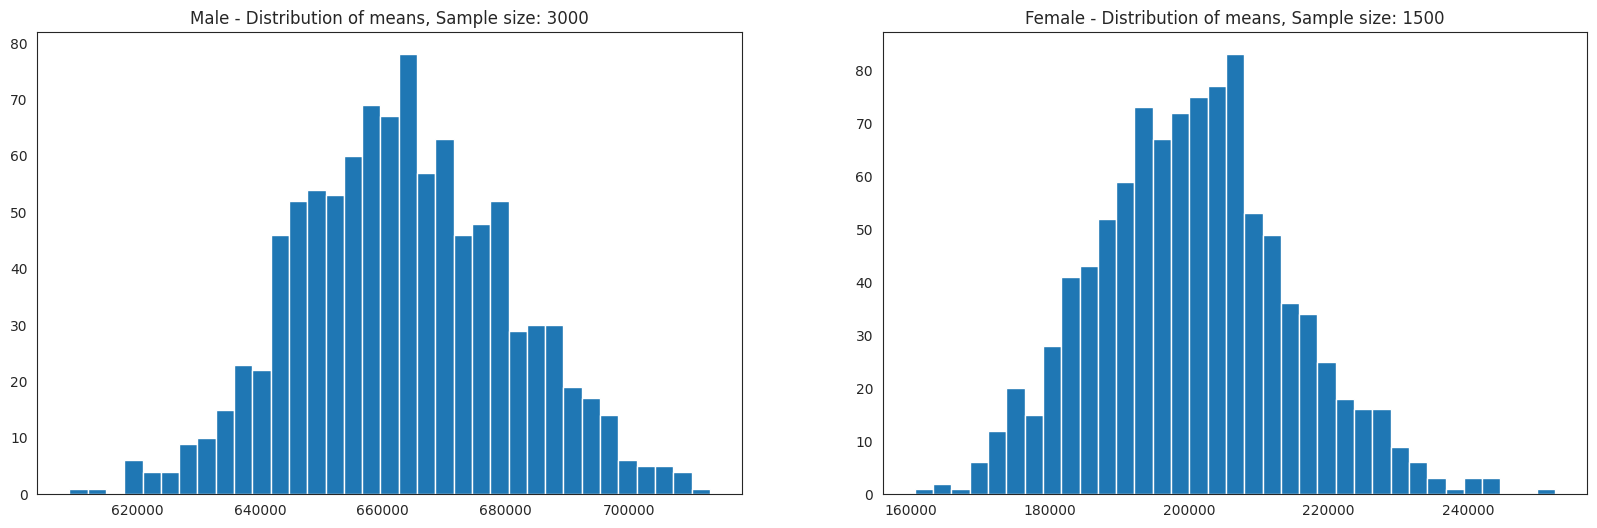

In [ ]:
fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

axis[0].hist(male_means, bins=35)
axis[1].hist(female_means, bins=35)
axis[0].set_title("Male - Distribution of means, Sample size: 3000")
axis[1].set_title("Female - Distribution of means, Sample size: 1500")

plt.show()

In [ ]:
print("Population mean - Mean of sample means of amount spend for Male: {:.2f}".format(np.mean(male_means)))
print("Population mean - Mean of sample means of amount spend for Female: {:.2f}".format(np.mean(female_means)))

print("\nMale - Sample mean: {:.2f} Sample std: {:.2f}".format(male_df['Purchase'].mean(), male_df['Purchase'].std()))
print("Female - Sample mean: {:.2f} Sample std: {:.2f}".format(female_df['Purchase'].mean(), female_df['Purchase'].std()))

Population mean - Mean of sample means of amount spend for Male: 663178.93
Population mean - Mean of sample means of amount spend for Female: 200412.35

Male - Sample mean: 663653.05 Sample std: 933096.80
Female - Sample mean: 201363.54 Sample std: 535828.17


**Observation**

Now using the **Central Limit Theorem** for the **population** we can say that:
1. Average amount spend by male customers is **9,26,341.86**
2. Average amount spend by female customers is **7,11,704.09**

In [ ]:
male_margin_of_error_clt = 1.96*male_df['Purchase'].std()/np.sqrt(len(male_df))
male_sample_mean = male_df['Purchase'].mean()
male_lower_lim = male_sample_mean - male_margin_of_error_clt
male_upper_lim = male_sample_mean + male_margin_of_error_clt

female_margin_of_error_clt = 1.96*female_df['Purchase'].std()/np.sqrt(len(female_df))
female_sample_mean = female_df['Purchase'].mean()
female_lower_lim = female_sample_mean - female_margin_of_error_clt
female_upper_lim = female_sample_mean + female_margin_of_error_clt

print("Male confidence interval of means: ({:.2f}, {:.2f})".format(male_lower_lim, male_upper_lim))
print("Female confidence interval of means: ({:.2f}, {:.2f})".format(female_lower_lim, female_upper_lim))

Male confidence interval of means: (639825.01, 687481.08)
Female confidence interval of means: (187680.36, 215046.73)


Now we can infer about the population that, **95% of the times**:

1. Average amount spend by male customer will lie in between: **(895617.83, 955070.97)**
2. Average amount spend by female customer will lie in between: **(673254.77, 750794.02)**

#### Doing the same activity for married vs unmarried

In [ ]:
amt_df = df.groupby(['User_ID', 'Marital_Status'])[['Purchase']].sum()
amt_df = amt_df.reset_index()
amt_df.head()

,User_ID,Marital_Status,Purchase
0,1000001,0,334093
1,1000001,1,0
2,1000002,0,810472
3,1000002,1,0
4,1000003,0,341635


In [ ]:
amt_df['Marital_Status'].value_counts()

0    5891
1    5891
Name: Marital_Status, dtype: int64

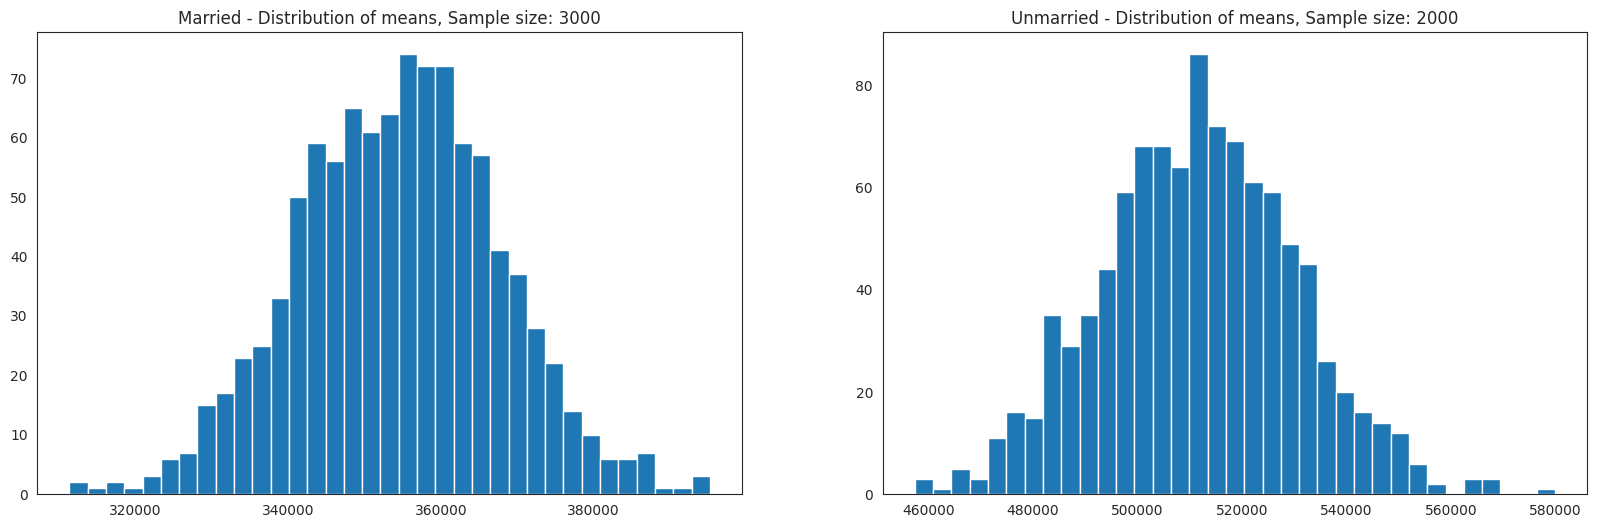

Population mean - Mean of sample means of amount spend for Married: 354413.62
Population mean - Mean of sample means of amount spend for Unmarried: 511623.97

Married - Sample mean: 354249.75 Sample std: 735314.88
Unmarried - Sample mean: 510766.84 Sample std: 843632.94


In [ ]:
marid_samp_size = 3000
unmarid_sample_size = 2000
num_repitions = 1000
marid_means = []
unmarid_means = []

for _ in range(num_repitions):
    marid_mean = amt_df[amt_df['Marital_Status']==1].sample(marid_samp_size, replace=True)['Purchase'].mean()
    unmarid_mean = amt_df[amt_df['Marital_Status']==0].sample(unmarid_sample_size, replace=True)['Purchase'].mean()

    marid_means.append(marid_mean)
    unmarid_means.append(unmarid_mean)


fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

axis[0].hist(marid_means, bins=35)
axis[1].hist(unmarid_means, bins=35)
axis[0].set_title("Married - Distribution of means, Sample size: 3000")
axis[1].set_title("Unmarried - Distribution of means, Sample size: 2000")

plt.show()

print("Population mean - Mean of sample means of amount spend for Married: {:.2f}".format(np.mean(marid_means)))
print("Population mean - Mean of sample means of amount spend for Unmarried: {:.2f}".format(np.mean(unmarid_means)))

print("\nMarried - Sample mean: {:.2f} Sample std: {:.2f}".format(amt_df[amt_df['Marital_Status']==1]['Purchase'].mean(), amt_df[amt_df['Marital_Status']==1]['Purchase'].std()))
print("Unmarried - Sample mean: {:.2f} Sample std: {:.2f}".format(amt_df[amt_df['Marital_Status']==0]['Purchase'].mean(), amt_df[amt_df['Marital_Status']==0]['Purchase'].std()))

In [ ]:
for val in ["Married", "Unmarried"]:

    new_val = 1 if val == "Married" else 0

    new_df = amt_df[amt_df['Marital_Status']==new_val]

    margin_of_error_clt = 1.96*new_df['Purchase'].std()/np.sqrt(len(new_df))
    sample_mean = new_df['Purchase'].mean()
    lower_lim = sample_mean - margin_of_error_clt
    upper_lim = sample_mean + margin_of_error_clt

    print("{} confidence interval of means: ({:.2f}, {:.2f})".format(val, lower_lim, upper_lim))

Married confidence interval of means: (335472.38, 373027.13)
Unmarried confidence interval of means: (489223.40, 532310.28)


### Calculating the average amount spent by Age

In [ ]:
amt_df = df.groupby(['User_ID', 'Age'])[['Purchase']].sum()
amt_df = amt_df.reset_index()
amt_df.head()

,User_ID,Age,Purchase
0,1000001,0-17,334093
1,1000001,18-25,0
2,1000001,26-35,0
3,1000001,36-45,0
4,1000001,46-50,0


In [ ]:
amt_df['Age'].value_counts()

0-17     5891
18-25    5891
26-35    5891
36-45    5891
46-50    5891
51-55    5891
55+      5891
Name: Age, dtype: int64

In [ ]:
sample_size = 200
num_repitions = 1000

all_means = {}

age_intervals = ['26-35', '36-45', '18-25', '46-50', '51-55', '55+', '0-17']
for age_interval in age_intervals:
    all_means[age_interval] = []

for age_interval in age_intervals:
    for _ in range(num_repitions):
        mean = amt_df[amt_df['Age']==age_interval].sample(sample_size, replace=True)['Purchase'].mean()
        all_means[age_interval].append(mean)

In [ ]:
for val in ['26-35', '36-45', '18-25', '46-50', '51-55', '55+', '0-17']:

    new_df = amt_df[amt_df['Age']==val]

    margin_of_error_clt = 1.96*new_df['Purchase'].std()/np.sqrt(len(new_df))
    sample_mean = new_df['Purchase'].mean()
    lower_lim = sample_mean - margin_of_error_clt
    upper_lim = sample_mean + margin_of_error_clt

    print("For age {} --> confidence interval of means: ({:.2f}, {:.2f})".format(val, lower_lim, upper_lim))

For age 26-35 --> confidence interval of means: (325226.35, 364561.66)
For age 36-45 --> confidence interval of means: (159958.40, 188563.04)
For age 18-25 --> confidence interval of means: (142318.86, 167933.62)
For age 46-50 --> confidence interval of means: (62258.26, 80618.47)
For age 51-55 --> confidence interval of means: (54450.95, 70179.72)
For age 55+ --> confidence interval of means: (28893.83, 39266.89)
For age 0-17 --> confidence interval of means: (18402.36, 27400.79)


# 5.Insights Based on CLT & CI

#### Confidence Interval by Gender
Now using the **Central Limit Theorem** for the **population**:
1. Average amount spend by **male** customers is **9,26,341.86**
2. Average amount spend by **female** customers is **7,11,704.09**

Now we can infer about the population that, **95% of the times**:

1. Average amount spend by **male** customer will lie in between: **(895617.83, 955070.97)**
2. Average amount spend by **female** customer will lie in between: **(673254.77, 750794.02)**


#### Confidence Interval by Marital_Status
1. **Married** confidence interval of means: **(806668.83, 880384.76)**
2. **Unmarried** confidence interval of means: **(848741.18, 912410.38)**


#### Confidence Interval by Age

1. For **age 26-35** --> confidence interval of means: **(945034.42, 1034284.21)**
2. For **age 36-45** --> confidence interval of means: **(823347.80, 935983.62)**
3. For **age 18-25** --> confidence interval of means: **(801632.78, 908093.46)**
4. For **age 46-50** --> confidence interval of means: **(713505.63, 871591.93)**
5. For **age 51-55** --> confidence interval of means: **(692392.43, 834009.42)**
6. For **age 55+** --> confidence interval of means: **(476948.26, 602446.23)**
7. For **age 0-17** --> confidence interval of means: **(527662.46, 710073.17)**

# 6. Recommendations
- As per the analysis females spend less than males on average, management needs to focus on their specific needs differently. Adding some additional offers for women can increase their spending.

- The management should have some offers on kids (0-17 years) in order to increase sales as there is lowest mean purchase in this age group.

- Management should conduct a survey for different age group, what they like most about some particular brand of specific product category to get more insights which will help businesses in customer aquistion & retention.

- Product Category B is quite demanded for 55+ age group. But, Management need to focus more on other categories for 55+ age group.

- Most of customer stayed more than 2 years  in same city having slightly lower mean purchase. Managment should perform research  for all the stores why it is low

- As product category 5 & 8 are quite demanding among females. In order to increase sale, management needs to introduce more items of these product categories in their stores

- As product category 1 & 5 are popular among both male and female, in order to increase sales management need to give additional offers and introduce some strategry regarding cross-sale or upsell.

- Male customers living in City_Category C spend more money than other male customers living in B or C, Selling more products in the City_Category C will help the company increase the revenue.


